In [ ]:
import pydicom

ds = pydicom.dcmread("slide.dcm")

# basic metadata from tutorial file
print(ds.Modality) # 'SM' = slide microscopy
print(ds.Rows, ds.Columns) # one frame/tile size
print(ds.NumberOfFrames) # tiles in this file
print(ds.TotalPixelMatrixColumns, ds.TotalPixelMatrixRows) # full image
print(ds.PhotometricInterpretation) # often YBR_FULL_422, not RGB
print(ds.DimensionOrganizationType) # TILED_FULL vs TILED_SPARSE

SM
240 240
1403
14441 5471
RGB
TILED_FULL


In [66]:
print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 222
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: VL Whole Slide Microscopy Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.5962.99.1.132039251.338821108.1640809579091.21.0
(0002,0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.5962.99.2
(0002,0013) Implementation Version Name         SH: 'PIXELMEDJAVA001'
(0002,0016) Source Application Entity Title     AE: 'OURAETITLE'
-------------------------------------------------
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY', 'VOLUME', 'RESAMPLED']
(0008,0012) Instance Creation Date              DA: '20220619'
(0008,0013) Instance Creation Time              TM: '233212.258'
(0008,0014) Instance Creator UID                UI: 1.3.6.1.4.

The print(ds) function returns the file's full metadata, with all fields available here: https://pydicom.github.io/pydicom/dev/tutorials/dataset_basics.html

DimensionOrganizationType tells if an image is TILED_FULL (all tiles included, including whitespace) or TILED_SPARSE (only tiles of interest)

In [14]:
# row and column spacing in microns (converted from mm)
shared_groups = ds.SharedFunctionalGroupsSequence[0]
pixel_measures = shared_groups.PixelMeasuresSequence[0]
spacing = pixel_measures.PixelSpacing

# default size is in mm
print(f"Row spacing: {spacing[0] * 1000} microns")
print(f"Column spacing: {spacing[1] * 1000} microns")

# objective lens power
if "OpticalPathSequence" in ds:
    for optical_path in ds.OpticalPathSequence:
        if "ObjectiveLensPower" in optical_path:
            power = optical_path.ObjectiveLensPower
            print(f"Objective Lens Power: {power}x")

Row spacing: 1.97690266602 microns
Column spacing: 1.97690266602 microns
Objective Lens Power: 20x


Question: a "script printing a labeled metadata summary" is mentioned in the tutorial file. What kinds of data is necessary? 

In [58]:
from wsidicom import WsiDicom

# generate thumbnail of whole slide
slide = WsiDicom.open("/Users/yahyaamjad/Downloads/Research/cptac_brca/01BR001/2.25.48791557373299768401597362411459861639/SM_1.3.6.1.4.1.5962.99.1.132039251.338821108.1640809579091.2.0")
for level in slide.levels:
    print(level.level, level.size)

0 Size(width=57767, height=21886)
2 Size(width=14441, height=5471)
4 Size(width=3610, height=1367)


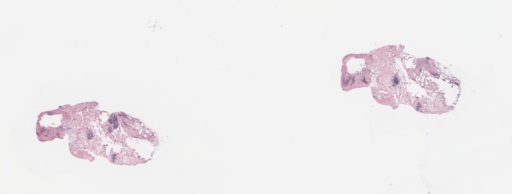

In [18]:
thumb = slide.read_thumbnail((512, 512))
thumb

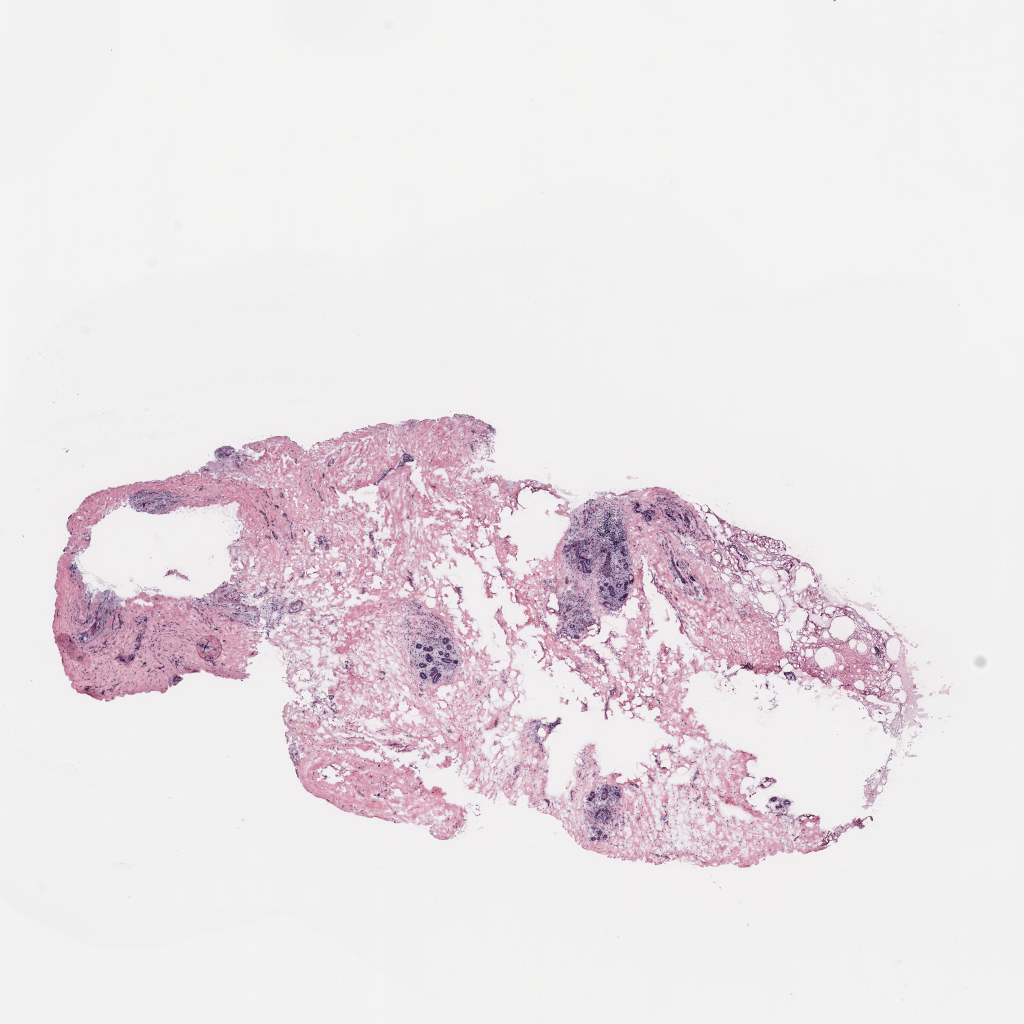

In [63]:
region = slide.read_region((200, 300), level=4, size=(1024, 1024)) # PIL RGB
region

In [ ]:
raw = ds.pixel_array
raw

array([[[[243, 243, 243],
         [243, 243, 243],
         [243, 243, 243],
         ...,
         [243, 244, 243],
         [243, 244, 243],
         [243, 244, 243]],

        [[243, 243, 243],
         [243, 243, 243],
         [243, 243, 243],
         ...,
         [243, 244, 243],
         [243, 244, 243],
         [243, 244, 243]],

        [[243, 243, 243],
         [243, 243, 243],
         [243, 243, 243],
         ...,
         [243, 244, 243],
         [243, 244, 243],
         [243, 244, 243]],

        ...,

        [[243, 243, 243],
         [243, 243, 243],
         [243, 243, 243],
         ...,
         [243, 243, 243],
         [243, 243, 243],
         [243, 243, 243]],

        [[243, 243, 243],
         [243, 243, 243],
         [243, 243, 243],
         ...,
         [243, 243, 243],
         [243, 243, 243],
         [243, 243, 243]],

        [[243, 243, 243],
         [243, 243, 243],
         [243, 243, 243],
         ...,
         [243, 243, 243],
        